In [84]:
# Cell 1 — Setup & Imports

import os
import json
import numpy as np
import pandas as pd
import torch
import shap
import glob

from sklearn.preprocessing import StandardScaler

In [85]:
# Cell 2 — Paths

BASE_PATH = "/content/drive/My Drive/mbti-tune"

DATA_PATH = f"{BASE_PATH}/data"
MODEL_PATH = f"{BASE_PATH}/models"
RAW_PATH = f"{DATA_PATH}/raw"
PROCESSED_PATH = f"{DATA_PATH}/processed"
MERGED_PATH = f"{DATA_PATH}/merged"

In [86]:
# Cell 3 — Discover available feature files

def find_files(name):
    return glob.glob(f"{BASE_PATH}/**/{name}", recursive=True)

print("feature files:")
for f in find_files("features.json"):
    print(f)

print("\nplaylist data files:")
for f in find_files("playlist_data*.csv"):
    print(f)

feature files:
/content/drive/My Drive/mbti-tune/data/merged/features.json
/content/drive/My Drive/mbti-tune/data/training/features.json

playlist data files:
/content/drive/My Drive/mbti-tune/data/merged/playlist_data.csv
/content/drive/My Drive/mbti-tune/data/processed/playlist_data_from_mbti_playlists.csv


In [87]:
# Cell 4 — Load best feature schema safely

candidate_files = [
    f"{PROCESSED_PATH}/playlist_features.json",
    f"{MERGED_PATH}/features.json",
    f"{DATA_PATH}/training/features.json"
]

feature_cols = None

for f in candidate_files:
    if os.path.exists(f):
        with open(f, "r") as file:
            data = json.load(file)
            if isinstance(data, dict):
                # sometimes stored as {"features": [...]}
                data = data.get("features", data.get("columns", []))
            feature_cols = data
            print(f"✅ Loaded feature set: {f}")
            print("Feature count:", len(feature_cols))
            break

assert feature_cols is not None, "No feature schema found"

✅ Loaded feature set: /content/drive/My Drive/mbti-tune/data/processed/playlist_features.json
Feature count: 44


In [88]:
# Cell 5 — Load dataset safely

df = pd.read_csv(f"{MERGED_PATH}/playlist_data.csv")

print("Raw shape:", df.shape)

# Keep only columns that exist
valid_features = [c for c in feature_cols if c in df.columns]

missing = set(feature_cols) - set(valid_features)
print("Missing features (safe ignored):", list(missing)[:20])

X = df[valid_features].copy()

print("Final feature matrix:", X.shape)

Raw shape: (4201, 54)
Missing features (safe ignored): []
Final feature matrix: (4201, 44)


In [89]:
# Cell 6 — Clean data

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("NaNs remaining:", X.isna().sum().sum())

NaNs remaining: 0


In [90]:
# Cell 7 — Load scaler safely

scaler_path = f"{PROCESSED_PATH}/playlist_scaler.pkl"

import joblib

scaler = joblib.load(scaler_path)

X_scaled = scaler.transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (4201, 44)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [91]:
# Cell 8 — Load model robustly

class PretrainedEncoder(torch.nn.Module):
    def __init__(self, input_dim, hidden=128, out_dim=16):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_scaled.shape[1]

model = PretrainedEncoder(input_dim=input_dim)

state_dict = torch.load(f"{MODEL_PATH}/encoder_114k_weights.pth", map_location="cpu")

# FIX: numeric -> named mapping
new_state = {}
for k, v in state_dict.items():
    if k.startswith("layers."):
        new_k = k.replace("layers.", "net.")
    else:
        new_k = k
    new_state[new_k] = v

try:
    model.load_state_dict(new_state, strict=False)
except Exception as e:
    print("Warning:", e)

model.eval()

print("Model loaded with input_dim =", input_dim)

Model loaded with input_dim = 44


In [92]:
# Cell 9 — SHAP wrapper

import torch.nn as nn

class WrappedModel(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)


wrapped = WrappedModel(model)

X_sample = torch.tensor(X_scaled[:200], dtype=torch.float32)

print("SHAP input:", X_sample.shape)

SHAP input: torch.Size([200, 44])


In [93]:
# Cell 10 — SHAP explanation

background = X_sample[:50]

try:
    explainer = shap.GradientExplainer(wrapped, background)
    shap_values = explainer.shap_values(X_sample)
    print("Using GradientExplainer")

except Exception as e:
    print("GradientExplainer failed, fallback:", e)
    explainer = shap.KernelExplainer(
        lambda x: wrapped(torch.tensor(x, dtype=torch.float32)).detach().numpy(),
        background.numpy()
    )
    shap_values = explainer.shap_values(X_sample.numpy())

Using GradientExplainer


/tmp/ipykernel_1394/4215786868.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy gl

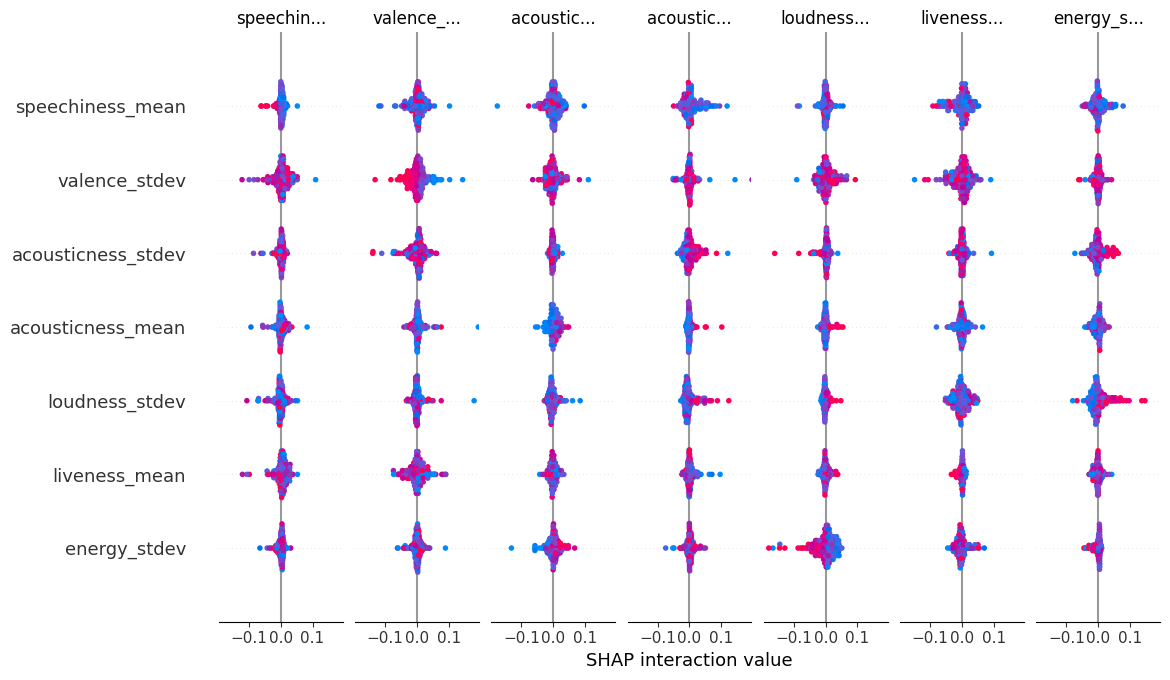

In [96]:
# Cell 11 — Clean SHAP visualization (no RNG warnings)

import numpy as np
import shap

# ensure deterministic behavior (optional but clean)
np.random.seed(42)

shap.summary_plot(
    shap_values,
    X_sample.numpy(),
    feature_names=valid_features,
    show=True
)

In [95]:
# Cell 12 — Debug consistency report

print("FINAL CHECKS")
print("- Feature count:", len(valid_features))
print("- Model input:", input_dim)
print("- Dataset shape:", X.shape)
print("- SHAP samples:", X_sample.shape)

assert X.shape[1] == input_dim, "Still mismatch between model and dataset"

FINAL CHECKS
- Feature count: 44
- Model input: 44
- Dataset shape: (4201, 44)
- SHAP samples: torch.Size([200, 44])
